In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\Walmart_Sales.csv")
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [3]:
# Clean column names
df.columns = df.columns.str.strip().str.lower()
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna()

df.head()

,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment
0,1,2010-05-02,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,2010-12-02,1641957.44,1,38.51,2.548,211.242170,8.106
4,1,2010-05-03,1554806.68,0,46.50,2.625,211.350143,8.106
5,1,2010-12-03,1439541.59,0,57.79,2.667,211.380643,8.106
8,1,2010-02-04,1594968.28,0,62.27,2.719,210.820450,7.808


In [4]:
df['weekly_sales'].sum()

np.float64(2718571558.01)

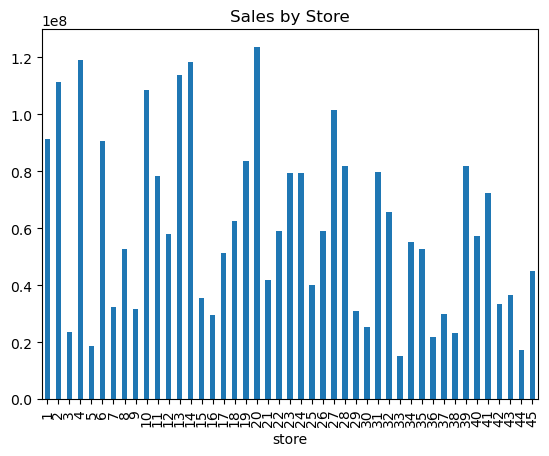

In [5]:
import matplotlib.pyplot as plt

df.groupby('store')['weekly_sales'].sum().plot(kind='bar')
plt.title("Sales by Store")
plt.show()

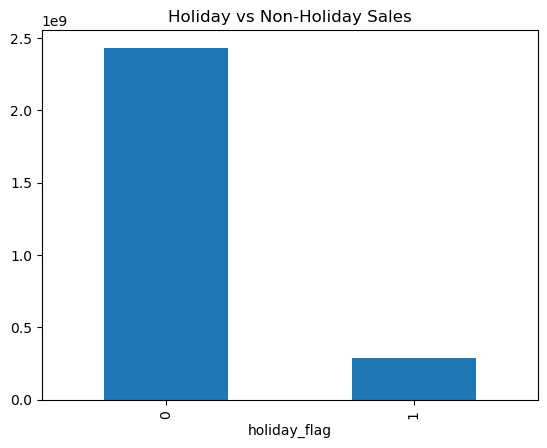

In [6]:
df.groupby('holiday_flag')['weekly_sales'].sum().plot(kind='bar')
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_2724\780948822.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df['date'].dt.month


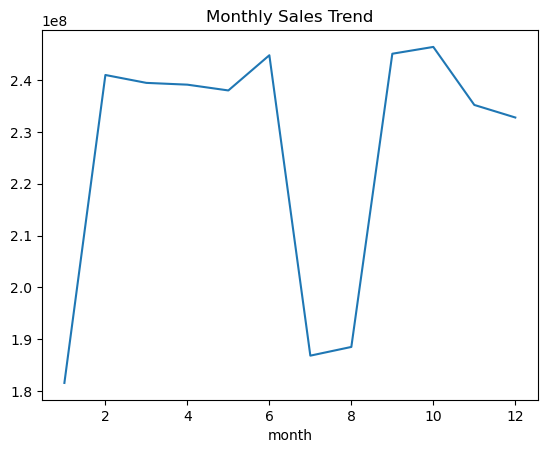

In [7]:
df['month'] = df['date'].dt.month
df.groupby('month')['weekly_sales'].sum().plot()
plt.title("Monthly Sales Trend")
plt.show()

In [9]:
df.to_csv("walmart_cleaned.csv", index=False)